In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure visualizations appear in the notebook
%matplotlib inline

# Load the dataset
# Ensure 'ENB2012_data.xlsx' is in your directory
try:
    df = pd.read_csv('ENB2012_data.csv')
    print("Data loaded successfully!")
except FileNotFoundError:
    print("File not found. Please check the file path.")

# Rename columns for easier access (X1 -> Compactness, etc.)
# This mapping is based on the dataset documentation
column_names = {
    'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Overall_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load',
    'Y2': 'Cooling_Load'
}

df = df.rename(columns=column_names)

# Display the first few rows and the data info
display(df.head())
print("-" * 30)
df.info()

Data loaded successfully!


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


We notice we have numerical data lying around in this dataset so we use RMSE as an evaluation metric to compare different models. 

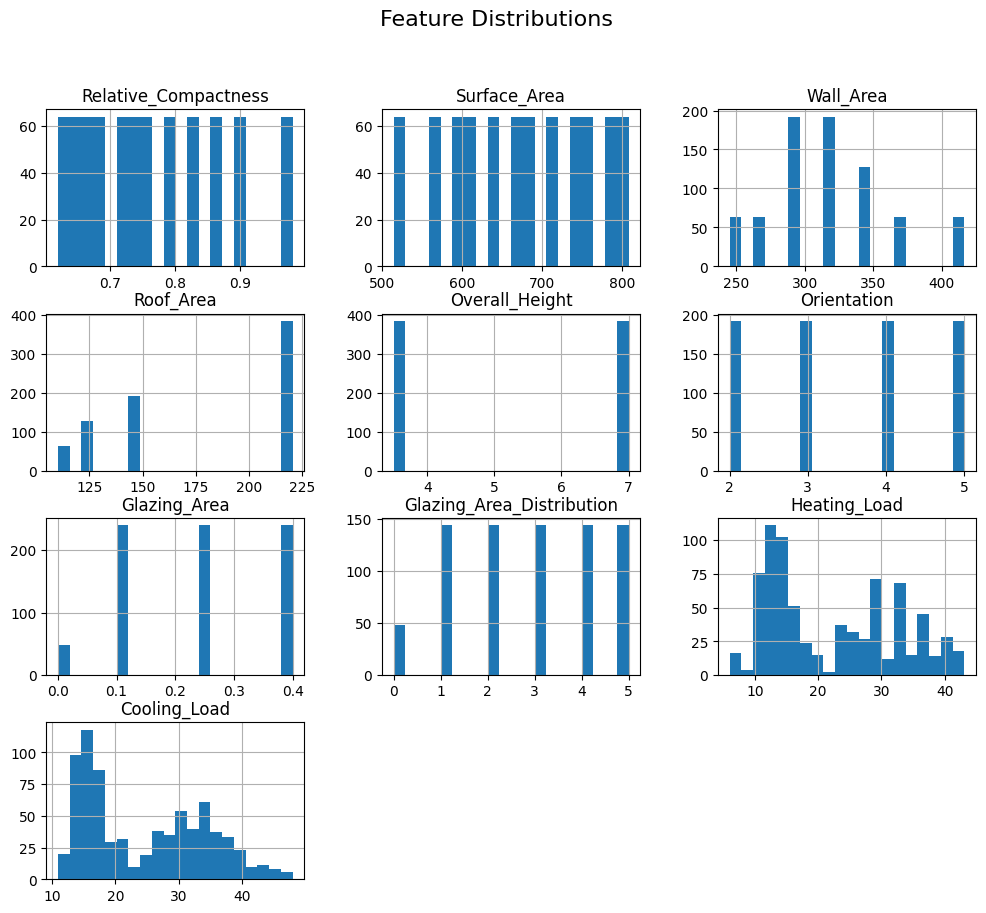

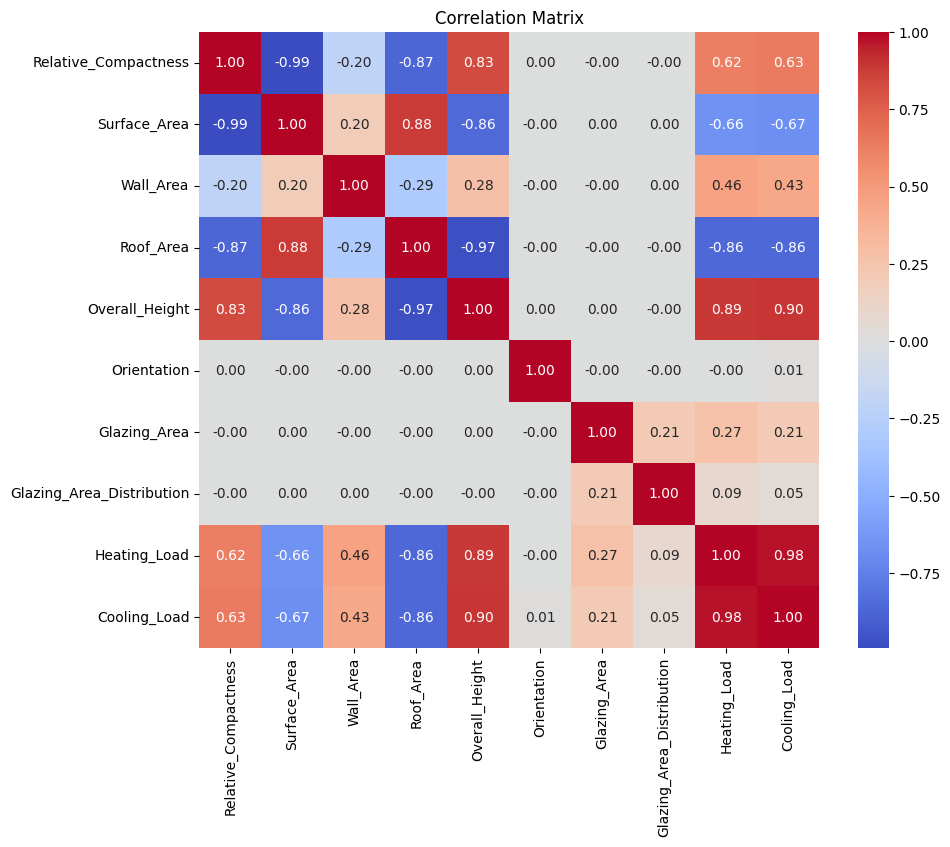

In [9]:
# --- EDA STEP ---
import seaborn as sns

# 1. Visualizing the distributions
# We want to see if our features are skewed or normal
df.hist(bins=20, figsize=(12, 10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# 2. Correlation Matrix
# This tells us which input features (X) actually matter for the output (Y)
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
# We will focus on Heating_Load for this benchmark
X = df.drop(['Heating_Load', 'Cooling_Load'], axis=1)
y = df['Heating_Load']

# 80% Training, 20% Testing
# random_state=42 ensures we get the same split every time (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (614, 8)
Testing shape: (154, 8)


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# --- MODEL 1: LINEAR REGRESSION (The Baseline) ---
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict
y_pred_lin = lin_reg.predict(X_test)
lin_mse = mean_squared_error(y_test, y_pred_lin)
lin_rmse = np.sqrt(lin_mse) # Root Mean Squared Error

print(f"Linear Regression RMSE: {lin_rmse:.4f}")


# --- MODEL 2: RANDOM FOREST (The Non-Linear Contender) ---
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(X_train, y_train)

# Predict
y_pred_forest = forest_reg.predict(X_test)
forest_mse = mean_squared_error(y_test, y_pred_forest)
forest_rmse = np.sqrt(forest_mse)

print(f"Random Forest RMSE:     {forest_rmse:.4f}")

Linear Regression RMSE: 3.0254
Random Forest RMSE:     0.4908


We get two RMSE errors, our MLP model must beat the lowest rmse error for it to be considered usefel !

Neural Networks calculate weights using gradient descent. If one feature is huge (e.g., Surface_Area = 800) and another is tiny (e.g., Compactness = 0.7), the gradients will go haywire, and the network won't learn efficiently.

In [12]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

# 1. SCALING (Mandatory for NNs)
scaler = StandardScaler()

# Fit only on training data to avoid data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. BUILD THE ARCHITECTURE
# We use a "Sequential" model (stack of layers)
model = keras.models.Sequential([
    # Hidden Layer 1: 64 neurons, ReLU activation to handle non-linearity
    keras.layers.Dense(64, activation="relu", input_shape=X_train.shape[1:]),
    
    # Hidden Layer 2: 32 neurons, refining features
    keras.layers.Dense(32, activation="relu"),
    
    # Output Layer: 1 neuron (Predicting a single number: Heating Load)
    # No activation function here because we want the raw number (e.g., 14.5)
    keras.layers.Dense(1)
])

# 3. COMPILE
# Optimizer: Adam (adjusts learning rate automatically, usually best default)
# Loss: Mean Squared Error (same as our metric)
model.compile(loss="mean_squared_error", optimizer="adam")

# 4. TRAIN (FIT)
# epochs=100: The model sees the dataset 100 times
# validation_split=0.2: It holds back 20% of training data to check itself live
print("Training Neural Network...")
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2, verbose=0)
print("Training Complete.")

Training Neural Network...


c:\Users\HP\Desktop\Machine Learning\california-housing-project\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Complete.


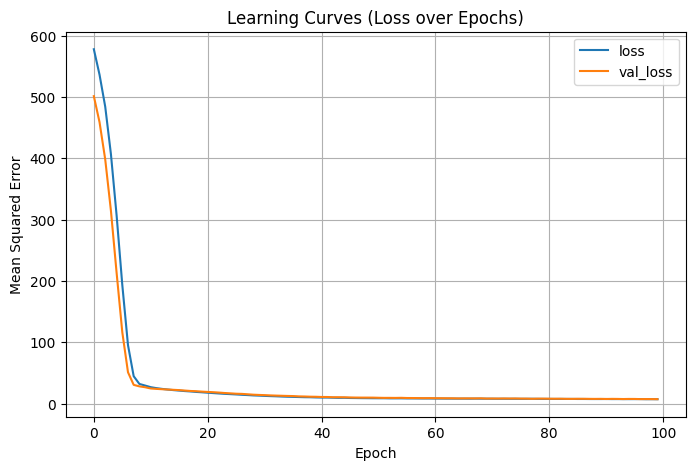

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
------------------------------
Linear Regression RMSE: 3.0254
Random Forest RMSE:     0.4908
Neural Network RMSE:    2.8277
------------------------------


In [13]:
# 1. PLOT LEARNING CURVES
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.title("Learning Curves (Loss over Epochs)")
plt.ylabel("Mean Squared Error")
plt.xlabel("Epoch")
plt.show()

# 2. FINAL EVALUATION
# Predict on the test set
y_pred_nn = model.predict(X_test_scaled)

# Calculate RMSE to compare with Random Forest
nn_mse = mean_squared_error(y_test, y_pred_nn)
nn_rmse = np.sqrt(nn_mse)

print("-" * 30)
print(f"Linear Regression RMSE: {lin_rmse:.4f}")
print(f"Random Forest RMSE:     {forest_rmse:.4f}")
print(f"Neural Network RMSE:    {nn_rmse:.4f}")
print("-" * 30)

c:\Users\HP\Desktop\Machine Learning\california-housing-project\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Improved Neural Network...
✅ Stopped after 287 epochs.
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002309E5C7380> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
------------------------------
Random Forest RMSE:      0.4908
Original NN RMSE:        2.8277
Tuned NN RMSE:           0.6208
------

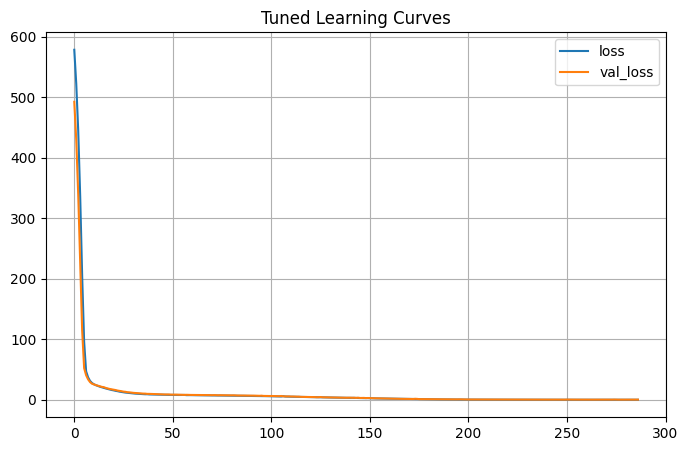

In [14]:
# --- IMPROVED TRAINING BLOCK ---

# 1. Redefine the model (We must reset it, otherwise it continues from where it left off)
model = keras.models.Sequential([
    keras.layers.Dense(64, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(64, activation="relu"), # Increased neurons in 2nd layer
    keras.layers.Dense(1)
])

model.compile(loss="mean_squared_error", optimizer="adam")

# 2. Add Early Stopping
# This callback monitors 'val_loss'. If it doesn't improve for 20 epochs, it stops.
# restore_best_weights=True ensures we keep the best version of the model, not the last one.
early_stopping = keras.callbacks.EarlyStopping(
    patience=20, 
    restore_best_weights=True,
    monitor='val_loss'
)

# 3. Train with more epochs + callback
print("Training Improved Neural Network...")
history = model.fit(
    X_train_scaled, y_train, 
    epochs=1000,           # Give it plenty of time
    validation_split=0.2, 
    callbacks=[early_stopping],
    verbose=0
)

print(f"✅ Stopped after {len(history.epoch)} epochs.")

# 4. Re-evaluate
y_pred_nn_tuned = model.predict(X_test_scaled)
nn_mse_tuned = mean_squared_error(y_test, y_pred_nn_tuned)
nn_rmse_tuned = np.sqrt(nn_mse_tuned)

print("-" * 30)
print(f"Random Forest RMSE:      {forest_rmse:.4f}")
print(f"Original NN RMSE:        {nn_rmse:.4f}")
print(f"Tuned NN RMSE:           {nn_rmse_tuned:.4f}")
print("-" * 30)

# 5. Plot the new learning curve
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.title("Tuned Learning Curves")
plt.show()